In [1]:
from pathlib import Path
import xarray as xr
import torch
import torch.nn.functional
from climanet.st_encoder_decoder import SpatioTemporalModel
from climanet.utils import set_seed, configure_compute_resources, plot_results, plot_histograms, plot_loss, data_preparation, read_st_data
from climanet.train import train_monthly_model, TrainConfig
from climanet.predict import predict_monthly_var, PredictionConfig
from climanet.dataset import STDataset, DataLoaderConfig

from tbparse import SummaryReader
import matplotlib.pyplot as plt

## Read data

In [2]:
# without diurnal cycle
data_folder = Path("./eso4clima/dc_data")
run_dir = Path("./runs_daily").resolve()

var_name = "tos"

# 1 month train, 1 month validation and test
daily_data = xr.open_mfdataset(data_folder / f"202101_day_ERA5dc_masked_{var_name}.nc")
daily_data_validation = xr.open_mfdataset(data_folder / f"202102_day_ERA5dc_masked_{var_name}.nc")
daily_data_test = xr.open_mfdataset(data_folder / f"202103_day_ERA5dc_masked_{var_name}.nc")

monthly_data = xr.open_mfdataset(data_folder / f"202101_mon_ERA5dc_full_{var_name}.nc")
monthly_data_validation = xr.open_mfdataset(data_folder / f"202102_mon_ERA5dc_full_{var_name}.nc")
monthly_data_test = xr.open_mfdataset(data_folder / f"202103_mon_ERA5dc_full_{var_name}.nc")

file_name = data_folder / "era5_lsm_bool.nc"  # downloded from era5 and regridded using the function `regrid_to_boundary_centered_grid`
lsm_mask = xr.open_dataset(file_name)
# lsm_mask = lsm_mask.rename({'latitude': 'lat', 'longitude': 'lon'})

## Subset data (for fast example)

In [3]:
# coordinates of subset
lon_subset = slice(-50, 50)  # one lon -179.9 is nan, check data
lat_subset = slice(-30, 10)

daily_subset = daily_data.sel(lon=lon_subset, lat=lat_subset)
monthly_subset = monthly_data.sel(lon=lon_subset, lat=lat_subset)
lsm_subset = lsm_mask.sel(lon=lon_subset, lat=lat_subset)  # True=Land

daily_validation_subset = daily_data_validation.sel(lon=lon_subset, lat=lat_subset)
monthly_validation_subset = monthly_data_validation.sel(lon=lon_subset, lat=lat_subset)

daily_test_subset = daily_data_test.sel(lon=lon_subset, lat=lat_subset)
monthly_test_subset = monthly_data_test.sel(lon=lon_subset, lat=lat_subset)

print(daily_subset[var_name].shape, monthly_subset[var_name].shape)  # (time, lat, lon)

(31, 160, 400) (1, 160, 400)


## Training workflow

### Build the model

In [4]:
# create the model (small)
set_seed()

In [16]:
patch_size = (1, 4, 4)
model = SpatioTemporalModel(patch_size=patch_size, overlap=2, embed_dim=64, dropout=0.2, hidden=64)

In [17]:
# Device and resources
device = "cpu"
compute_threads = 4
dataloader_num_workers = 1
model = configure_compute_resources(model, device=device, compute_threads=compute_threads, dataloader_num_workers=dataloader_num_workers)

### Build the datasets

#### Prepare the train data

In [7]:
data_dir = Path(f"{run_dir}/data_train")
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = data_preparation(
    daily_subset[var_name], monthly_subset[var_name], calculate_residuals=True, is_hourly=False, save_to_zarr=True, run_dir=data_dir,
)

In [8]:
# read data 
data_dir = f"{run_dir}/data_train"
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = read_st_data(data_path=data_dir, var_name=var_name)

In [9]:
# create dataset config
num_patches = (10, 10)
spatial_patch_size = (patch_size[1]*num_patches[0], patch_size[2]*num_patches[1])
stride = (spatial_patch_size[0] // 5, spatial_patch_size[1] // 5)

dataset_train = STDataset(
    input_da=input_da,
    input_da_nan_mask=input_da_nan_mask,
    monthly_da=monthly_da,
    padded_days_mask=padded_days_mask,
    time_features=time_features,
    land_mask=lsm_subset["lsm"],
    patch_size=(1, *spatial_patch_size),  # based on the patch_size in model
    stride=stride,
    sh_embed_dim=96,
    sh_order_L = 10,
    verbose=True,
    load_lazy=True,
)
print(len(dataset_train))

Creating dataset:
Patch grid (m x i x j): 1 x 16 x 46 = 736 patches
Overlap: 32 pixels (height), 32 pixels (width)
736


#### Prepare validation data

In [10]:
data_dir = f"{run_dir}/data_validation"
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = data_preparation(
    daily_validation_subset[var_name], monthly_validation_subset[var_name], calculate_residuals=True, is_hourly=False, save_to_zarr=True, run_dir=data_dir,
)

In [11]:
# read data 
data_dir = f"{run_dir}/data_validation"
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = read_st_data(data_path=data_dir, var_name=var_name)

In [12]:
num_patches = (10, 10)
spatial_patch_size = (patch_size[1]*num_patches[0], patch_size[2]*num_patches[1])
stride = (spatial_patch_size[0] // 5, spatial_patch_size[1] // 5)

dataset_validation = STDataset(
    input_da=input_da,
    input_da_nan_mask=input_da_nan_mask,
    monthly_da=monthly_da,
    padded_days_mask=padded_days_mask,
    time_features=time_features,
    land_mask=lsm_subset["lsm"],
    patch_size=(1, *spatial_patch_size),  # based on the patch_size in model
    stride=stride,
    sh_embed_dim=96,
    sh_order_L = 10,
    verbose=True,
    load_lazy=True,
)
print(len(dataset_validation))

Creating dataset:
Patch grid (m x i x j): 1 x 16 x 46 = 736 patches
Overlap: 32 pixels (height), 32 pixels (width)
736


In [13]:
# create dataloader config
dataloader_config = DataLoaderConfig(
    batch_size=10,
    shuffle=True,
    num_workers= dataloader_num_workers,
    pin_memory=False,
    persistent_workers=True,
    device=device,
    multiprocessing_context="spawn", # keep this when num_workers >0 and lazy data
)
dataloader_config

DataLoaderConfig(batch_size=10, shuffle=True, num_workers=1, pin_memory=False, persistent_workers=True, device='cpu', multiprocessing_context='spawn')

In [18]:
# create training config
training_config = TrainConfig(
    calculate_residuals=True,
    num_epoch=100,
    patience=10,
    accumulation_steps=2,
    optimizer_lr=1e-3,
    device=device,
    verbose=True,
    verbose_epoch_interval=20,
    tune_checkpoint=False,
    store_model=True,
)
training_config

TrainConfig(calculate_residuals=True, num_epoch=100, patience=10, accumulation_steps=2, optimizer_lr=0.001, device='cpu', verbose=True, verbose_epoch_interval=20, tune_checkpoint=False, store_model=True)

### Start training loop

In [19]:
%%time
# verbose is True
trained_model = train_monthly_model(
    model=model,
    dataset_train=dataset_train,
    dataloader_config=dataloader_config,
    training_config=training_config,
    dataset_validation=dataset_validation,
    run_dir=run_dir,
)

Epoch 0: gap between train and val loss: -0.043650
Epoch 0: best_loss = 0.027357
Epoch 20: gap between train and val loss: 0.007366
Epoch 20: best_loss = 0.022358
Epoch 40: gap between train and val loss: 0.008106
Epoch 40: best_loss = 0.022358
Epoch 60: gap between train and val loss: 0.008217
Epoch 60: best_loss = 0.022358
Epoch 80: gap between train and val loss: 0.008329
Epoch 80: best_loss = 0.022358
Training complete. Best loss: 0.022358
Model saved to runs_daily/best_model.pth
CPU times: user 1h 19min 40s, sys: 45.8 s, total: 1h 20min 26s
Wall time: 1h 12min 59s


## Inspect results and compare

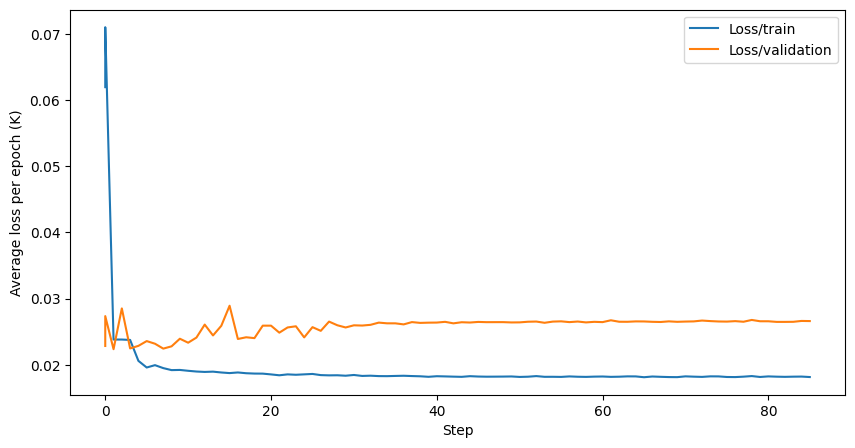

In [20]:
plot_loss(run_dir, list_loss_var=["Loss/train", "Loss/validation"], unit="K")

#### Prepare the test data

In [21]:
data_dir = f"{run_dir}/data_test"
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = data_preparation(
    daily_test_subset[var_name], monthly_test_subset[var_name], calculate_residuals=True, is_hourly=False, save_to_zarr=True, run_dir=data_dir,
)

In [22]:
# read data 
data_dir = f"{run_dir}/data_test"
input_da, input_da_nan_mask, monthly_da, padded_days_mask, time_features = read_st_data(data_path=data_dir, var_name=var_name)

In [23]:
num_patches = (10, 10)
spatial_patch_size = (patch_size[1]*num_patches[0], patch_size[2]*num_patches[1])
stride = (spatial_patch_size[0] // 5, spatial_patch_size[1] // 5)

dataset_test = STDataset(
    input_da=input_da,
    input_da_nan_mask=input_da_nan_mask,
    monthly_da=monthly_da,
    padded_days_mask=padded_days_mask,
    time_features=time_features,
    land_mask=lsm_subset["lsm"],
    patch_size=(1, *spatial_patch_size),  # based on the patch_size in model
    stride=stride,
    sh_embed_dim=96,
    sh_order_L = 10,
    verbose=True,
    load_lazy=False,
)
print(len(dataset_test))

Creating dataset:
Patch grid (m x i x j): 1 x 16 x 46 = 736 patches
Overlap: 32 pixels (height), 32 pixels (width)
736


In [24]:
# create dataloader config
dataloader_config = DataLoaderConfig(
    batch_size=10,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    persistent_workers=False,
    device=device,
    multiprocessing_context=None, # keep this when num_workers >0 and lazy data
)
dataloader_config

DataLoaderConfig(batch_size=10, shuffle=True, num_workers=0, pin_memory=False, persistent_workers=False, device='cpu', multiprocessing_context=None)

In [25]:
# create prediction config
prediction_config = PredictionConfig(
    calculate_residuals=True,
    return_numpy=True,
    save_predictions=True,
    return_loss=False,
    device=device,
    verbose=True,
)

In [26]:
# inference on test data, verbose is True
predictions = predict_monthly_var(
    model=f"{run_dir}/best_model.pth",
    dataset=dataset_test,  
    dataloader_config=dataloader_config,
    prediction_config=prediction_config,
    run_dir=run_dir,
)

Processed batch 1/74, with loss: 0.0303
Processed batch 2/74, with loss: 0.0230
Processed batch 3/74, with loss: 0.0260
Processed batch 4/74, with loss: 0.0476
Processed batch 5/74, with loss: 0.0320
Processed batch 6/74, with loss: 0.0272
Processed batch 7/74, with loss: 0.0160
Processed batch 8/74, with loss: 0.0379
Processed batch 9/74, with loss: 0.0344
Processed batch 10/74, with loss: 0.0424
Processed batch 11/74, with loss: 0.0210
Processed batch 12/74, with loss: 0.0278
Processed batch 13/74, with loss: 0.0393
Processed batch 14/74, with loss: 0.0251
Processed batch 15/74, with loss: 0.0259
Processed batch 16/74, with loss: 0.0251
Processed batch 17/74, with loss: 0.0386
Processed batch 18/74, with loss: 0.0295
Processed batch 19/74, with loss: 0.0437
Processed batch 20/74, with loss: 0.0355
Processed batch 21/74, with loss: 0.0326
Processed batch 22/74, with loss: 0.0258
Processed batch 23/74, with loss: 0.0321
Processed batch 24/74, with loss: 0.0207
Processed batch 25/74, wi

In [27]:
predictions_res = xr.open_dataset(f"{run_dir}/202103_{var_name}_prediction_residual.nc")

In [28]:
# add to monthly average
input_data_averaged = daily_test_subset.resample({"time": "MS"}).mean(skipna=True)
input_data_averaged["time"] = monthly_test_subset["time"]
predictions = input_data_averaged[var_name] + predictions_res[var_name]

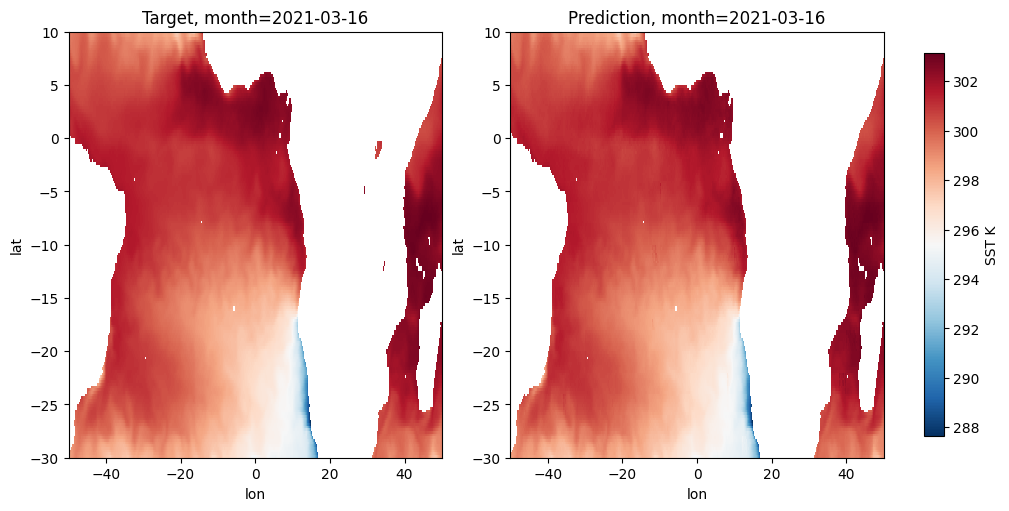

In [29]:
ocean = ~lsm_subset["lsm"].values
masked_target = monthly_test_subset[var_name].where(ocean)
masked_pred = predictions.where(ocean)
plot_results(masked_target, masked_pred, label="SST K", title=("Target", "Prediction"))

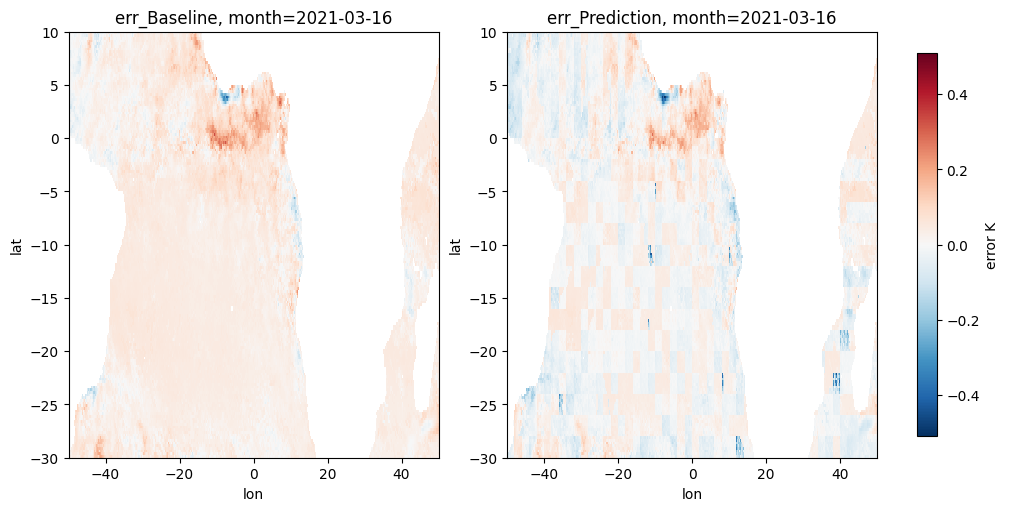

In [30]:
err_baseline = (monthly_test_subset[var_name] - input_data_averaged[var_name])   # M - mean(D)
err_predictions = (monthly_test_subset[var_name] - predictions)  # M - M_hat

ocean = ~lsm_subset["lsm"].values
masked_err_baseline = err_baseline.where(ocean)
masked_err_predictions = err_predictions.where(ocean) 

plot_results(masked_err_baseline, masked_err_predictions, label="error K", title=("err_Baseline", "err_Prediction"), error=True)

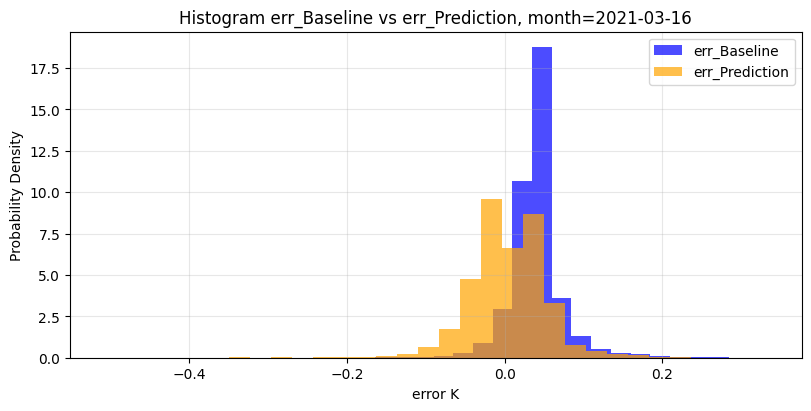

In [31]:
plot_histograms(masked_err_baseline, masked_err_predictions, label="error K", legend_labels=("err_Baseline", "err_Prediction"))